# Core Operations

[Core Operations — OpenCV Tutorials](https://docs.opencv.org/5.0/py_tutorials/py_core/py_table_of_contents_core.html)

## Basic Operations on Images

[Basic Operations on Images — OpenCV Tutorials](https://docs.opencv.org/5.0/py_tutorials/py_core/py_basic_ops/py_basic_ops.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Accessing and Modifying pixel values

In [2]:
img = cv2.imread("sample_dori-tan.jpg")

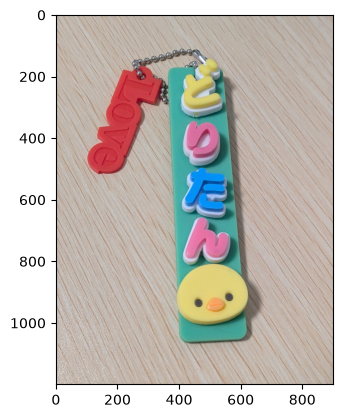

In [3]:
fig, axes = plt.subplots()
axes.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

ピクセル(BGR)へのアクセス

In [4]:
px = img[100,100]
px

array([179, 189, 199], dtype=uint8)

青色

In [5]:
blue = px[0]
blue

np.uint8(179)

In [6]:
img[100, 100, 0]

np.uint8(179)

ピクセルの変更

In [7]:
img_tmp = img.copy()
img_tmp[100, 100] = [255,255,255]
img_tmp[100, 100]

array([255, 255, 255], dtype=uint8)

### Accessing Image Properties

shape: `(rows, cols, channels)`

In [8]:
img.shape

(1200, 900, 3)

size: `rows * cols * channels`

In [9]:
img.size

3240000

In [10]:
img.size == img.shape[0] * img.shape[1] * img.shape[2]

True

In [11]:
img.dtype

dtype('uint8')

### Image ROI

画像の切り抜き

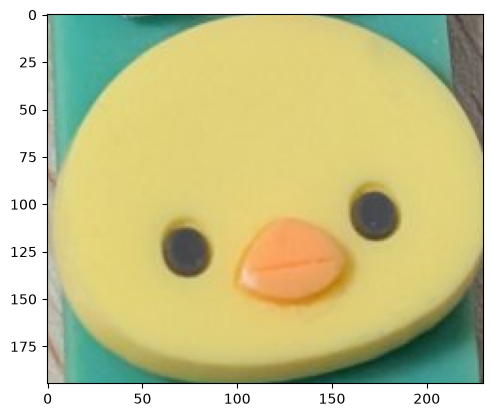

In [12]:
doritan = img[810:1005, 390:620]
fig, axes = plt.subplots()
axes.imshow(cv2.cvtColor(doritan, cv2.COLOR_BGR2RGB))
plt.show()

In [13]:
doritan.shape

(195, 230, 3)

画像の貼り付け

In [14]:
img_tmp = img.copy()
loc = (600, 100)
img_tmp[loc[0]:loc[0]+doritan.shape[0], loc[1]:loc[1]+doritan.shape[1]] = doritan

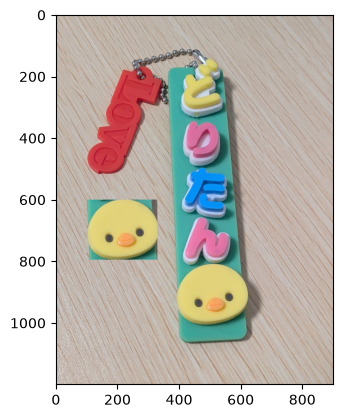

In [15]:
fig, axes = plt.subplots()
axes.imshow(cv2.cvtColor(img_tmp, cv2.COLOR_BGR2RGB))
plt.show()

### Splitting and Merging Image Channels

In [16]:
b, g, r = cv2.split(img)

青チャンネル

In [17]:
b.shape

(1200, 900)

In [18]:
np.array_equal(b, img[:, :, 0])

True

青チャンネル表示（グレースケース表示）

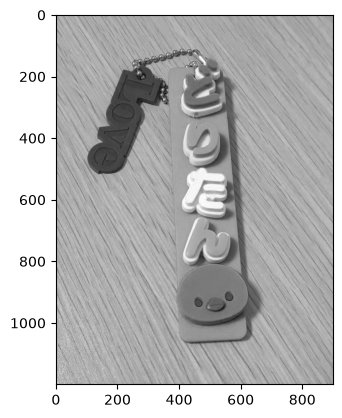

In [19]:
fig, axes = plt.subplots()
axes.imshow(b, cmap="gray")
plt.show()

青チャンネル表示（カラー表示）

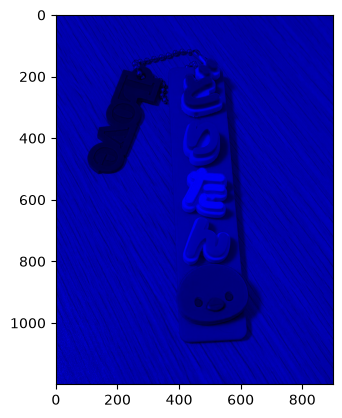

In [20]:
zeros = np.zeros_like(b)
blue_visual = cv2.merge((b, zeros, zeros))
fig, axes = plt.subplots()
axes.imshow(cv2.cvtColor(blue_visual, cv2.COLOR_BGR2RGB))
plt.show()

### Making Borders for Images (Padding)

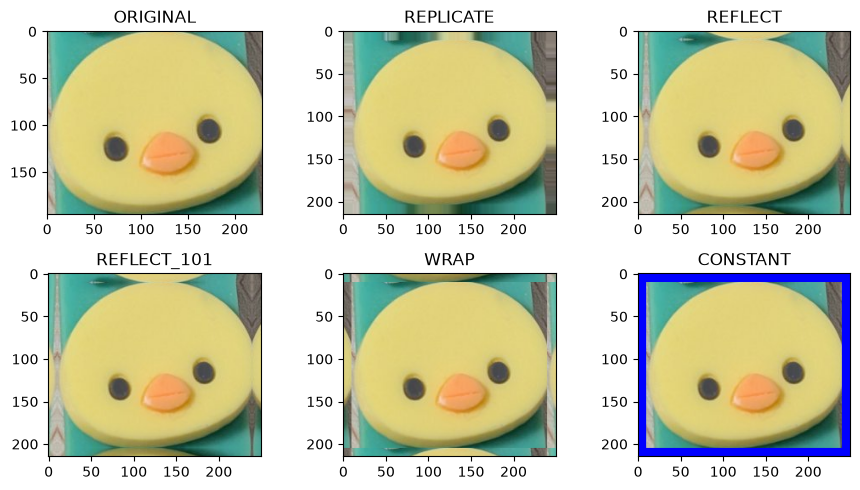

In [21]:
replicate = cv2.copyMakeBorder(doritan,10,10,10,10,cv2.BORDER_REPLICATE)
reflect = cv2.copyMakeBorder(doritan,10,10,10,10,cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(doritan,10,10,10,10,cv2.BORDER_REFLECT_101)
wrap = cv2.copyMakeBorder(doritan,10,10,10,10,cv2.BORDER_WRAP)
BLUE = (255,0,0)
constant= cv2.copyMakeBorder(doritan,10,10,10,10,cv2.BORDER_CONSTANT,value=BLUE)

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes[0, 0].set_title("ORIGINAL")
axes[0, 0].imshow(cv2.cvtColor(doritan, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("REPLICATE")
axes[0, 1].imshow(cv2.cvtColor(replicate, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title("REFLECT")
axes[0, 2].imshow(cv2.cvtColor(reflect, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("REFLECT_101")
axes[1, 0].imshow(cv2.cvtColor(reflect101, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("WRAP")
axes[1, 1].imshow(cv2.cvtColor(wrap, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("CONSTANT")
axes[1, 2].imshow(cv2.cvtColor(constant, cv2.COLOR_BGR2RGB))
fig.tight_layout()
plt.show()

#### BORDER_REFLECT と BORDER_REFLECT_101

- `BORDER_REFLECT`: 鏡映の軸は「aの外側の境界線（配列の外）」
    - ...f e d c b **a | a** b c d e f g h
- `BORDER_REFLECT_101`: 鏡映の軸は「aという画素そのもの」
    - ...g f e d c b | **a** b c d e f g h

In [22]:
line = np.array([[0, 255, 0]])
reflect = cv2.copyMakeBorder(line,0,0,3,3,cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(line,0,0,3,3,cv2.BORDER_REFLECT_101)

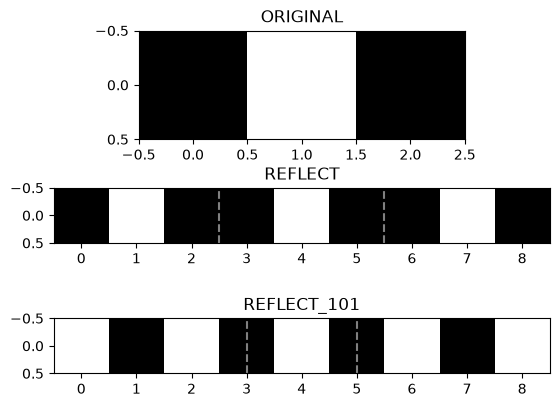

In [23]:
fig, axes = plt.subplots(3, 1)
axes[0].set_title("ORIGINAL")
axes[0].imshow(line,cmap="gray")
axes[1].set_title("REFLECT")
axes[1].imshow(reflect,cmap="gray")
axes[1].axvline(x=2.5, color="grey", linestyle="dashed")
axes[1].axvline(x=5.5, color="grey", linestyle="dashed")
axes[2].set_title("REFLECT_101")
axes[2].imshow(reflect101,cmap="gray")
axes[2].axvline(x=3, color="grey", linestyle="dashed")
axes[2].axvline(x=5, color="grey", linestyle="dashed")
plt.show()

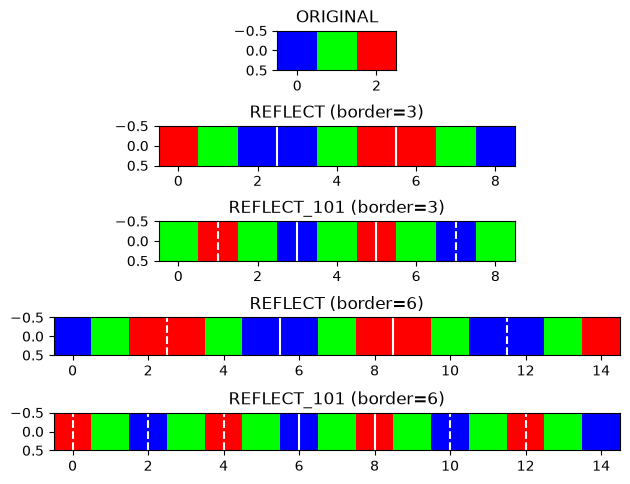

In [24]:
fig, axes = plt.subplots(5, 1)
axes[0].set_title("ORIGINAL")
line = np.array([[[255, 0, 0], [0, 255, 0], [0, 0, 255]]], dtype=np.uint8)
axes[0].imshow(cv2.cvtColor(line, cv2.COLOR_BGR2RGB))

border=3
axes[1].set_title(f"REFLECT (border={border})")
reflect = cv2.copyMakeBorder(line,0,0,border,border,cv2.BORDER_REFLECT)
axes[1].imshow(cv2.cvtColor(reflect, cv2.COLOR_BGR2RGB))
axes[1].axvline(x=2.5, color="white")
axes[1].axvline(x=5.5, color="white")
axes[2].set_title(f"REFLECT_101 (border={border})")
reflect101 = cv2.copyMakeBorder(line,0,0,border,border,cv2.BORDER_REFLECT_101)
axes[2].imshow(cv2.cvtColor(reflect101, cv2.COLOR_BGR2RGB))
axes[2].axvline(x=1, color="white", linestyle="dashed")
axes[2].axvline(x=3, color="white")
axes[2].axvline(x=5, color="white")
axes[2].axvline(x=7, color="white", linestyle="dashed")

border=6
axes[3].set_title(f"REFLECT (border={border})")
reflect = cv2.copyMakeBorder(line,0,0,border,border,cv2.BORDER_REFLECT)
axes[3].imshow(cv2.cvtColor(reflect, cv2.COLOR_BGR2RGB))
axes[3].axvline(x=2.5, color="white", linestyle="dashed")
axes[3].axvline(x=5.5, color="white")
axes[3].axvline(x=8.5, color="white")
axes[3].axvline(x=11.5, color="white", linestyle="dashed")
axes[4].set_title(f"REFLECT_101 (border={border})")
reflect101 = cv2.copyMakeBorder(line,0,0,border,border,cv2.BORDER_REFLECT_101)
axes[4].imshow(cv2.cvtColor(reflect101, cv2.COLOR_BGR2RGB))
axes[4].axvline(x=0, color="white", linestyle="dashed")
axes[4].axvline(x=2, color="white", linestyle="dashed")
axes[4].axvline(x=4, color="white", linestyle="dashed")
axes[4].axvline(x=6, color="white")
axes[4].axvline(x=8, color="white")
axes[4].axvline(x=10, color="white", linestyle="dashed")
axes[4].axvline(x=12, color="white", linestyle="dashed")
fig.tight_layout()
plt.show()